In [ ]:
 import pandas as pd

In [ ]:
df=pd.read_csv('bestsellers with categories.csv')

In [ ]:
print(df.head())

                                                Name  \
0                      10-Day Green Smoothie Cleanse   
1                                  11/22/63: A Novel   
2            12 Rules for Life: An Antidote to Chaos   
3                             1984 (Signet Classics)   
4  5,000 Awesome Facts (About Everything!) (Natio...   

                     Author  User Rating  Reviews  Price  Year        Genre  
0                  JJ Smith          4.7    17350      8  2016  Non Fiction  
1              Stephen King          4.6     2052     22  2011      Fiction  
2        Jordan B. Peterson          4.7    18979     15  2018  Non Fiction  
3             George Orwell          4.7    21424      6  2017      Fiction  
4  National Geographic Kids          4.8     7665     12  2019  Non Fiction  


In [ ]:
print(df.shape)

(550, 7)


In [ ]:
print(df.columns)

Index(['Name', 'Author', 'User Rating', 'Reviews', 'Price', 'Year', 'Genre'], dtype='object')


In [ ]:
print(df.describe())

       User Rating       Reviews       Price         Year
count   550.000000    550.000000  550.000000   550.000000
mean      4.618364  11953.281818   13.100000  2014.000000
std       0.226980  11731.132017   10.842262     3.165156
min       3.300000     37.000000    0.000000  2009.000000
25%       4.500000   4058.000000    7.000000  2011.000000
50%       4.700000   8580.000000   11.000000  2014.000000
75%       4.800000  17253.250000   16.000000  2017.000000
max       4.900000  87841.000000  105.000000  2019.000000


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.rename(columns={'Name':'Title','Year':'Publication Year','User Rating':'Rating'},inplace=True)

In [ ]:
print(df.columns)

Index(['Title', 'Author', 'Rating', 'Reviews', 'Price', 'Publication Year',
       'Genre'],
      dtype='object')


In [ ]:
df["Price"]=df["Price"].astype(float)

In [ ]:
#Analyzing Author Popularity
author_counts=df['Author'].value_counts()
print(author_counts)

Author
Jeff Kinney                           12
Suzanne Collins                       11
Gary Chapman                          11
Rick Riordan                          11
American Psychological Association    10
                                      ..
Maurice Sendak                         1
Cheryl Strayed                         1
The Staff of The Late Show with       1
Geneen Roth                            1
Ken Follett                            1
Name: count, Length: 248, dtype: int64


In [ ]:
#Average Rating by Genre
avg_rating_by_genre=df.groupby('Genre')['Rating'].mean()
print(avg_rating_by_genre)

Genre
Fiction        4.648333
Non Fiction    4.595161
Name: Rating, dtype: float64


In [ ]:
#Yearwise Trend Analysis
yearly_books=df.groupby("Publication Year").size()
print(yearly_books.sort_index())

Publication Year
2009    50
2010    50
2011    50
2012    50
2013    50
2014    50
2015    50
2016    50
2017    50
2018    50
2019    50
dtype: int64


In [ ]:
#Rating and Price Correlation
correlation=df['Rating'].corr(df['Price'])
print(f"correlation between Rating and Price {correlation:.3f}")

correlation between Rating and Price -0.133


In [ ]:
#Top Authors by Average rating
top_authors_by_Rating=(df.groupby("Author")["Rating"].mean().sort_values(ascending=False))
print(top_authors_by_Rating.head(10))


Author
Alice Schertle           4.9
Bill Martin Jr.          4.9
Chip Gaines              4.9
Dav Pilkey               4.9
Emily Winfield Martin    4.9
Eric Carle               4.9
Lin-Manuel Miranda       4.9
Jill Twiss               4.9
Sarah Young              4.9
Sherri Duskey Rinker     4.9
Name: Rating, dtype: float64


In [ ]:
#Genre wise Price and Rating Analysis
genre_analysis = df.groupby("Genre").agg({ "Price": ["mean", "max", "min"],"Rating": "mean"})
print(genre_analysis)


                 Price                Rating
                  mean    max  min      mean
Genre                                       
Fiction      10.850000   82.0  0.0  4.648333
Non Fiction  14.841935  105.0  0.0  4.595161


In [ ]:
#Identify Premium Books
df["Premium"] = df["Price"] > df["Price"].mean()

premium_stats = df.groupby("Premium")["Rating"].mean()
print(premium_stats)


Premium
False    4.649860
True     4.560104
Name: Rating, dtype: float64


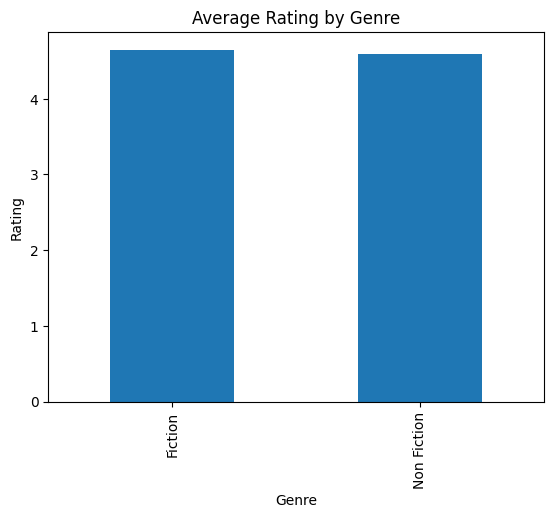

In [ ]:
# Average rating by Genre
import matplotlib.pyplot as plt
avg_rating_by_genre.plot(kind="bar", title="Average Rating by Genre")
plt.ylabel("Rating")
plt.show()

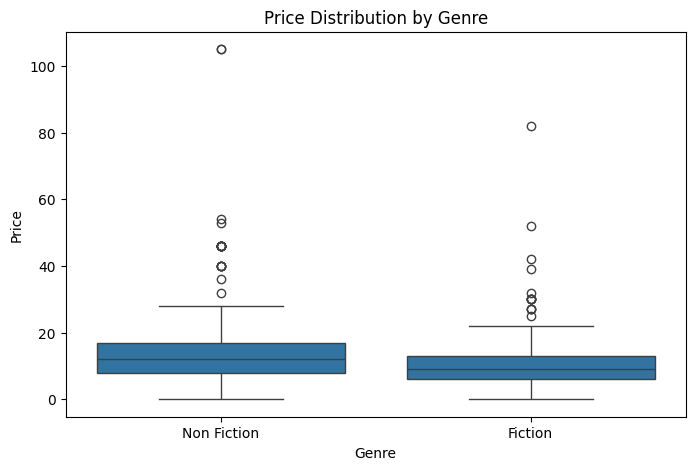

In [ ]:
#Price Distribution by Genre
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x="Genre", y="Price", data=df)
plt.title("Price Distribution by Genre")
plt.show()

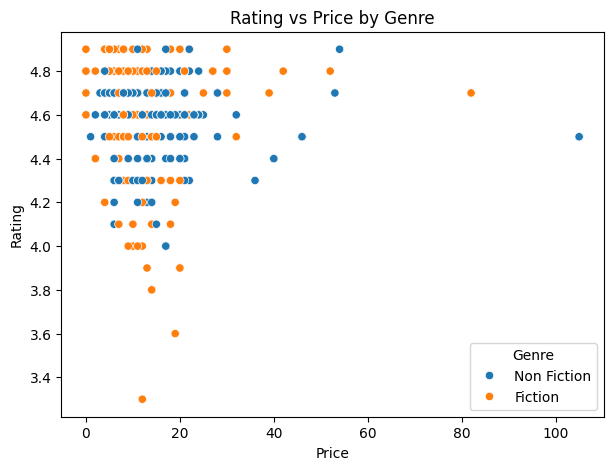

In [ ]:
# Rating and Prices
plt.figure(figsize=(7,5))
sns.scatterplot(x="Price", y="Rating", hue="Genre", data=df)
plt.title("Rating vs Price by Genre")
plt.show()


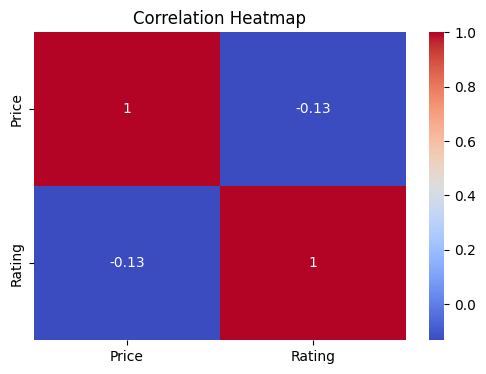

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[["Price", "Rating"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# Hypothesis Testing Q: Do Expensive Books have Higher Ratings than Cheaper ones
# Price Based Groups
from scipy.stats import ttest_ind

average_price = df["Price"].mean()

premium_books = df[df["Price"] > average_price]["Rating"]
budget_books = df[df["Price"] <= average_price]["Rating"]


In [ ]:
t_stat, p_value = ttest_ind(premium_books, budget_books)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Statistically significant difference in ratings.")
else:
    print("No statistically significant difference in ratings.")


T-statistic: -4.503000810873089
P-value: 8.190934970309897e-06
Statistically significant difference in ratings.


In [ ]:
author_counts.head(10).to_csv("Amazon_author_popularity.csv")
avg_rating_by_genre.to_csv("Amazon_avg_rating_by_genre.csv")
yearly_books.to_csv("Amazon_yearly_books.csv")
top_authors_by_Rating.to_csv("Amazon_top_authors_by_Rating.csv")


In [ ]:
# Predicting Ratings Based on Price, Year and Genre

df_encoded = pd.get_dummies(df,columns=["Genre"],drop_first=True)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X=df_encoded.drop(["Rating","Title","Author"],axis=1)
y=df_encoded["Rating"]

In [ ]:
# Train-test Split
X_train, X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
# Model Training
model= LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Model Evaluation
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 0.05457395587918382
R-squared: 0.048768559293972835


In [ ]:
# factors influencing ratings
feature_importance = pd.Series(
    model.coef_, index=X.columns
).sort_values()

print(feature_importance)


Premium             -0.091664
Genre_Non Fiction   -0.056902
Reviews             -0.000002
Price                0.001002
Publication Year     0.018429
dtype: float64


In [ ]:
results = pd.DataFrame({
    "Actual Rating": y_test,
    "Predicted Rating": y_pred
})

results.to_csv("rating_predictions.csv", index=False)
